In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('data/HR/train.csv')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
df.shape

(54808, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [5]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


*There is no large difference in the Median and Mean , but Mean is little higher in most columns, so we can its right skewed*

*Also, max values are reasonable , so we can say outlier may be present or may not*

In [6]:
df.duplicated().sum()  

np.int64(0)

*There are not any duplicate value*

In [ ]:
# Null Values Function
def null_values_table(df):
    null_values = df.isnull().sum()
    null_percentage = (null_values / len(df)) * 100
    null_table = pd.DataFrame({'Null Values': null_values, 'Percentage': null_percentage})
    print(f"Total Null Values sum: {df.isnull().sum().sum()}")
    print(f"Total Null Values percentage: {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")
    return null_table

In [11]:
null_values_table(df)


Total Null Values sum: 6533
Total Null Values percentage: 0.92%


,Null Values,Percentage
employee_id,0,0.000000
department,0,0.000000
region,0,0.000000
education,2409,4.395344
gender,0,0.000000
recruitment_channel,0,0.000000
no_of_trainings,0,0.000000
age,0,0.000000
previous_year_rating,4124,7.524449
length_of_service,0,0.000000


*Null values only present in the education(4.3%) and previous year rating (7.5%). Total 0.92% is NULL*

<Axes: >

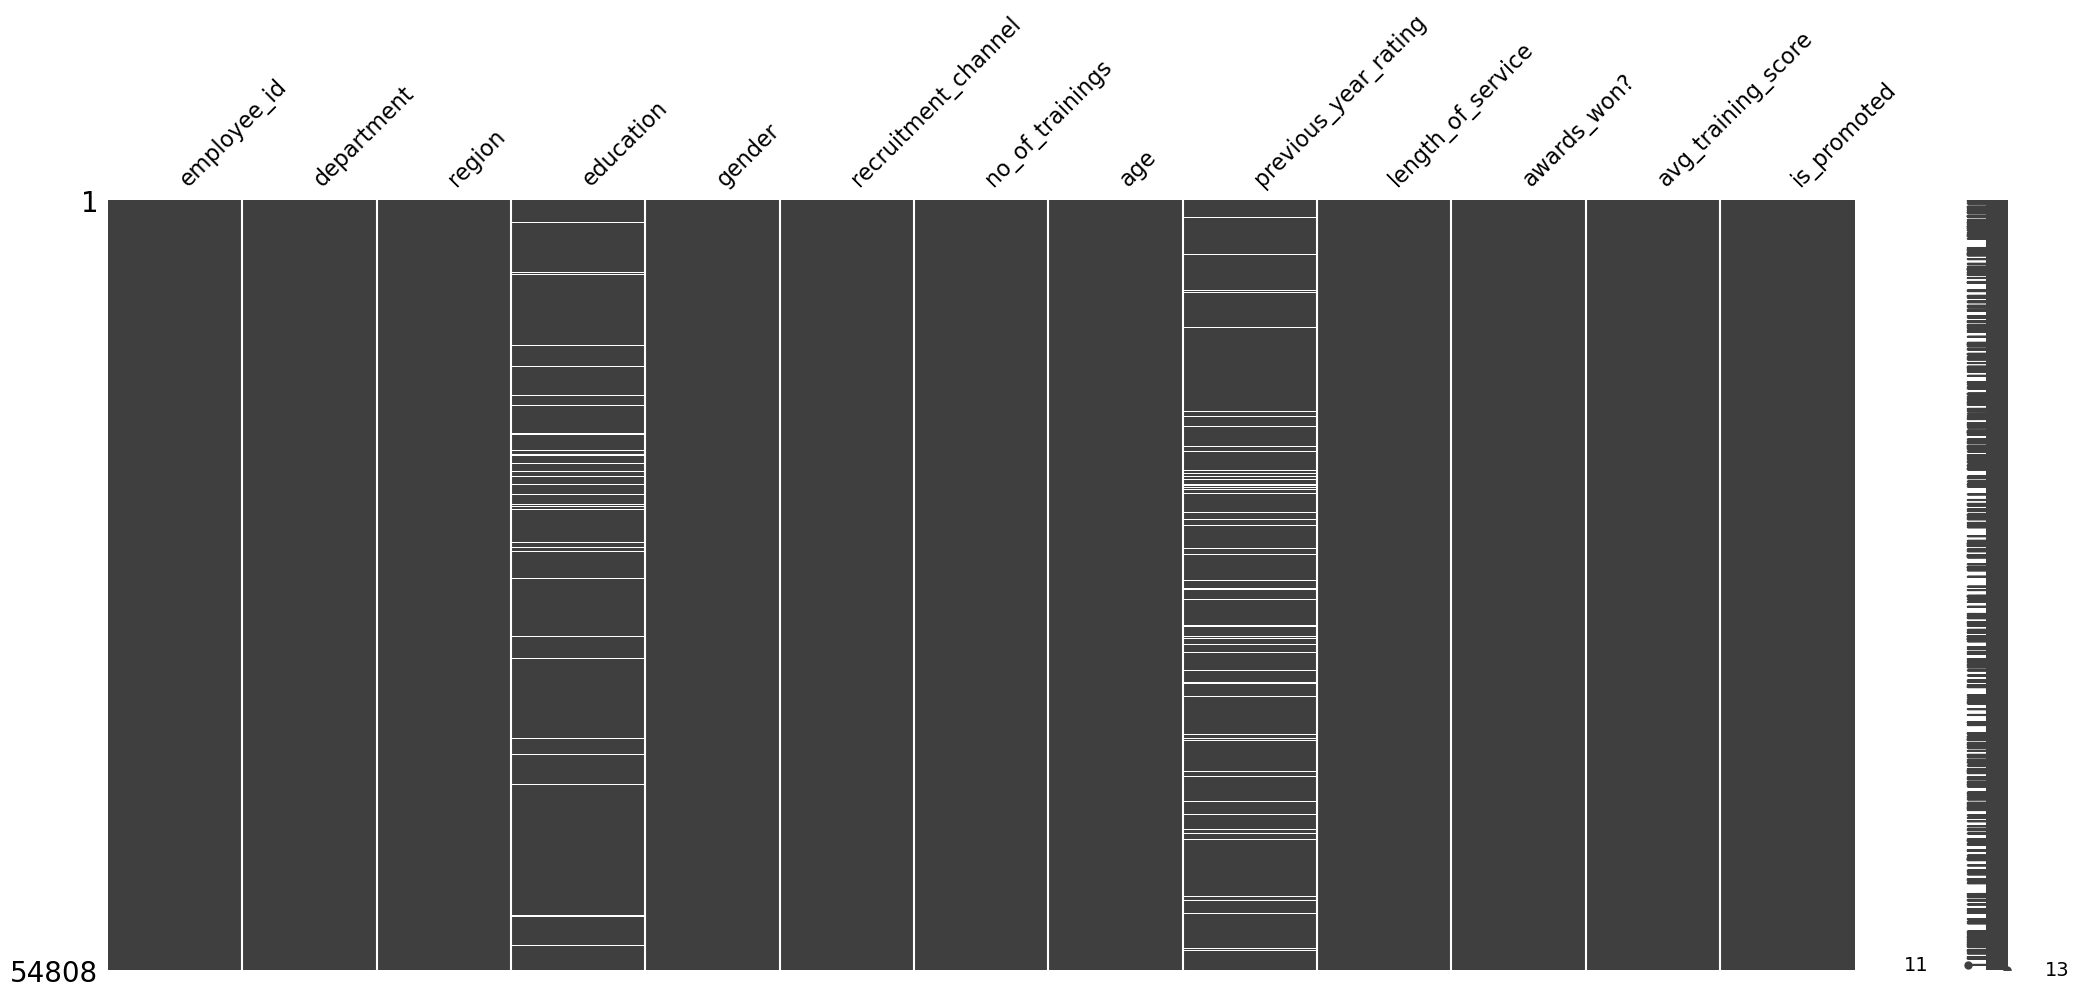

In [12]:
import missingno as msno
msno.matrix(df)

*white lines show the presence of null values in the education and previous year rating column.*

<Axes: >

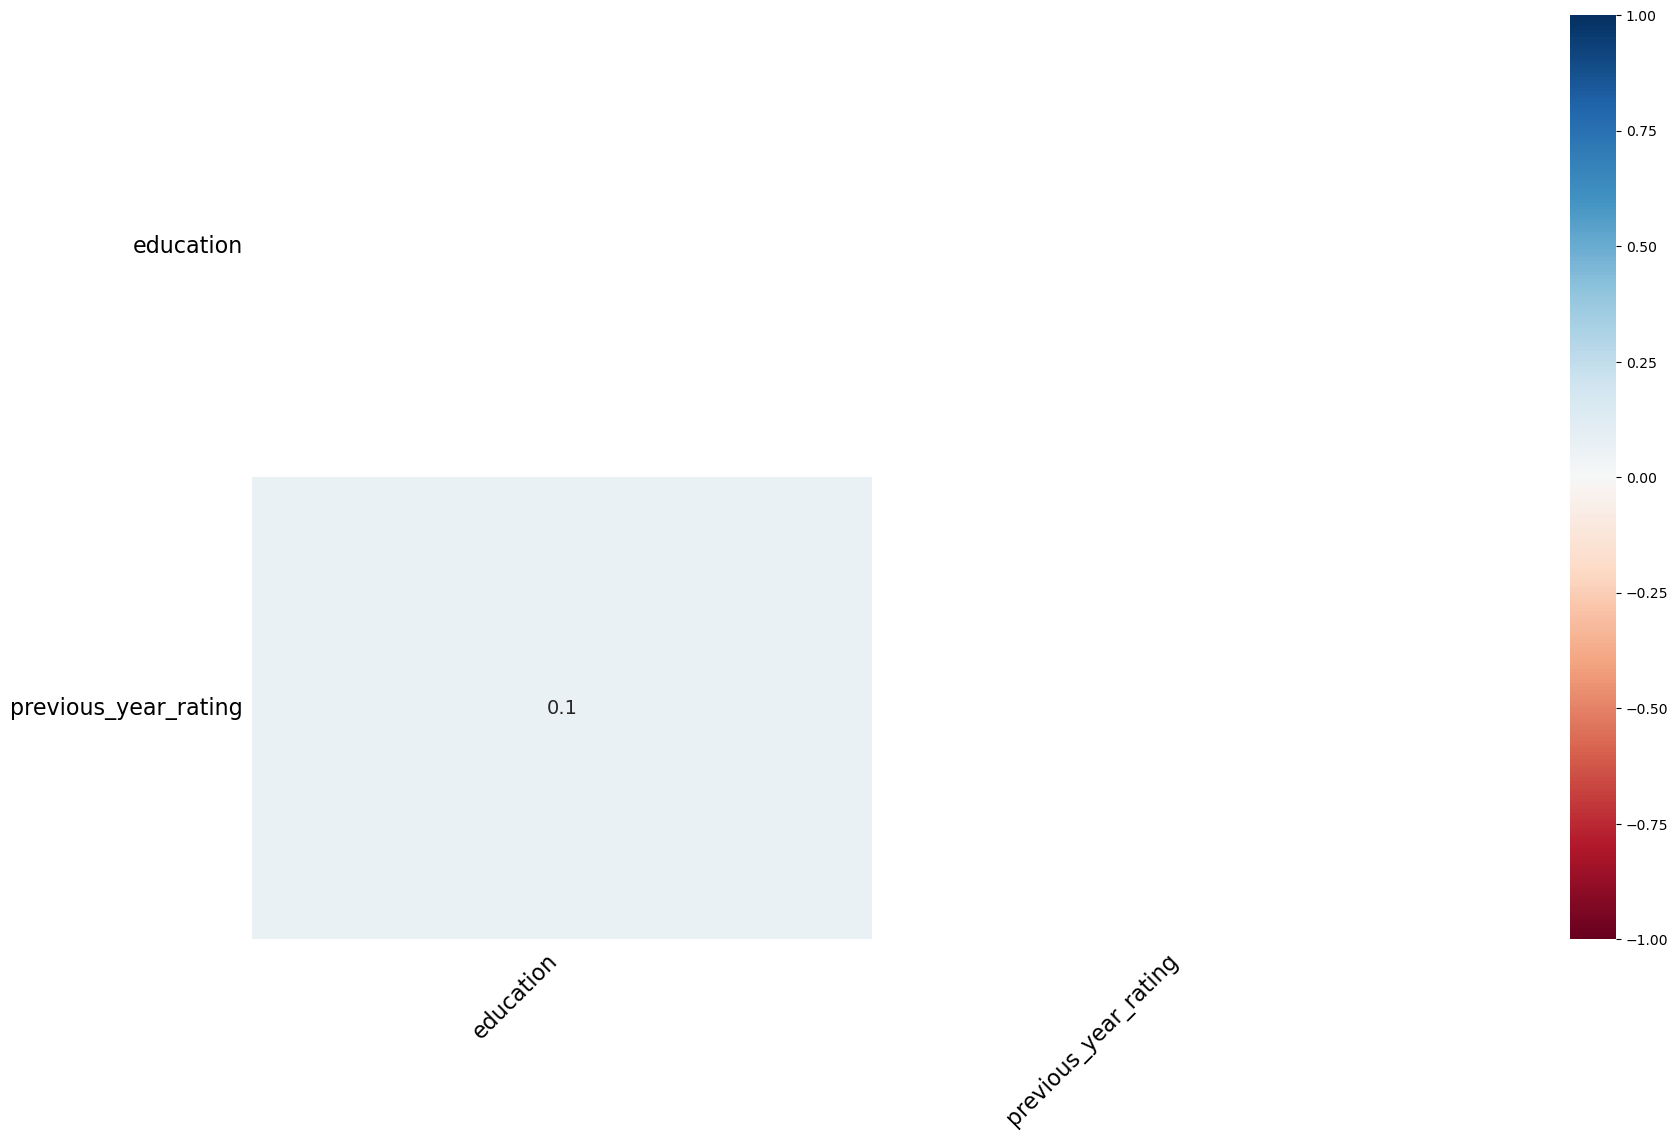

In [14]:
msno.heatmap(df)

*Both column are very weak related on missing value , we can assume as missing at completely at random*

<Axes: >

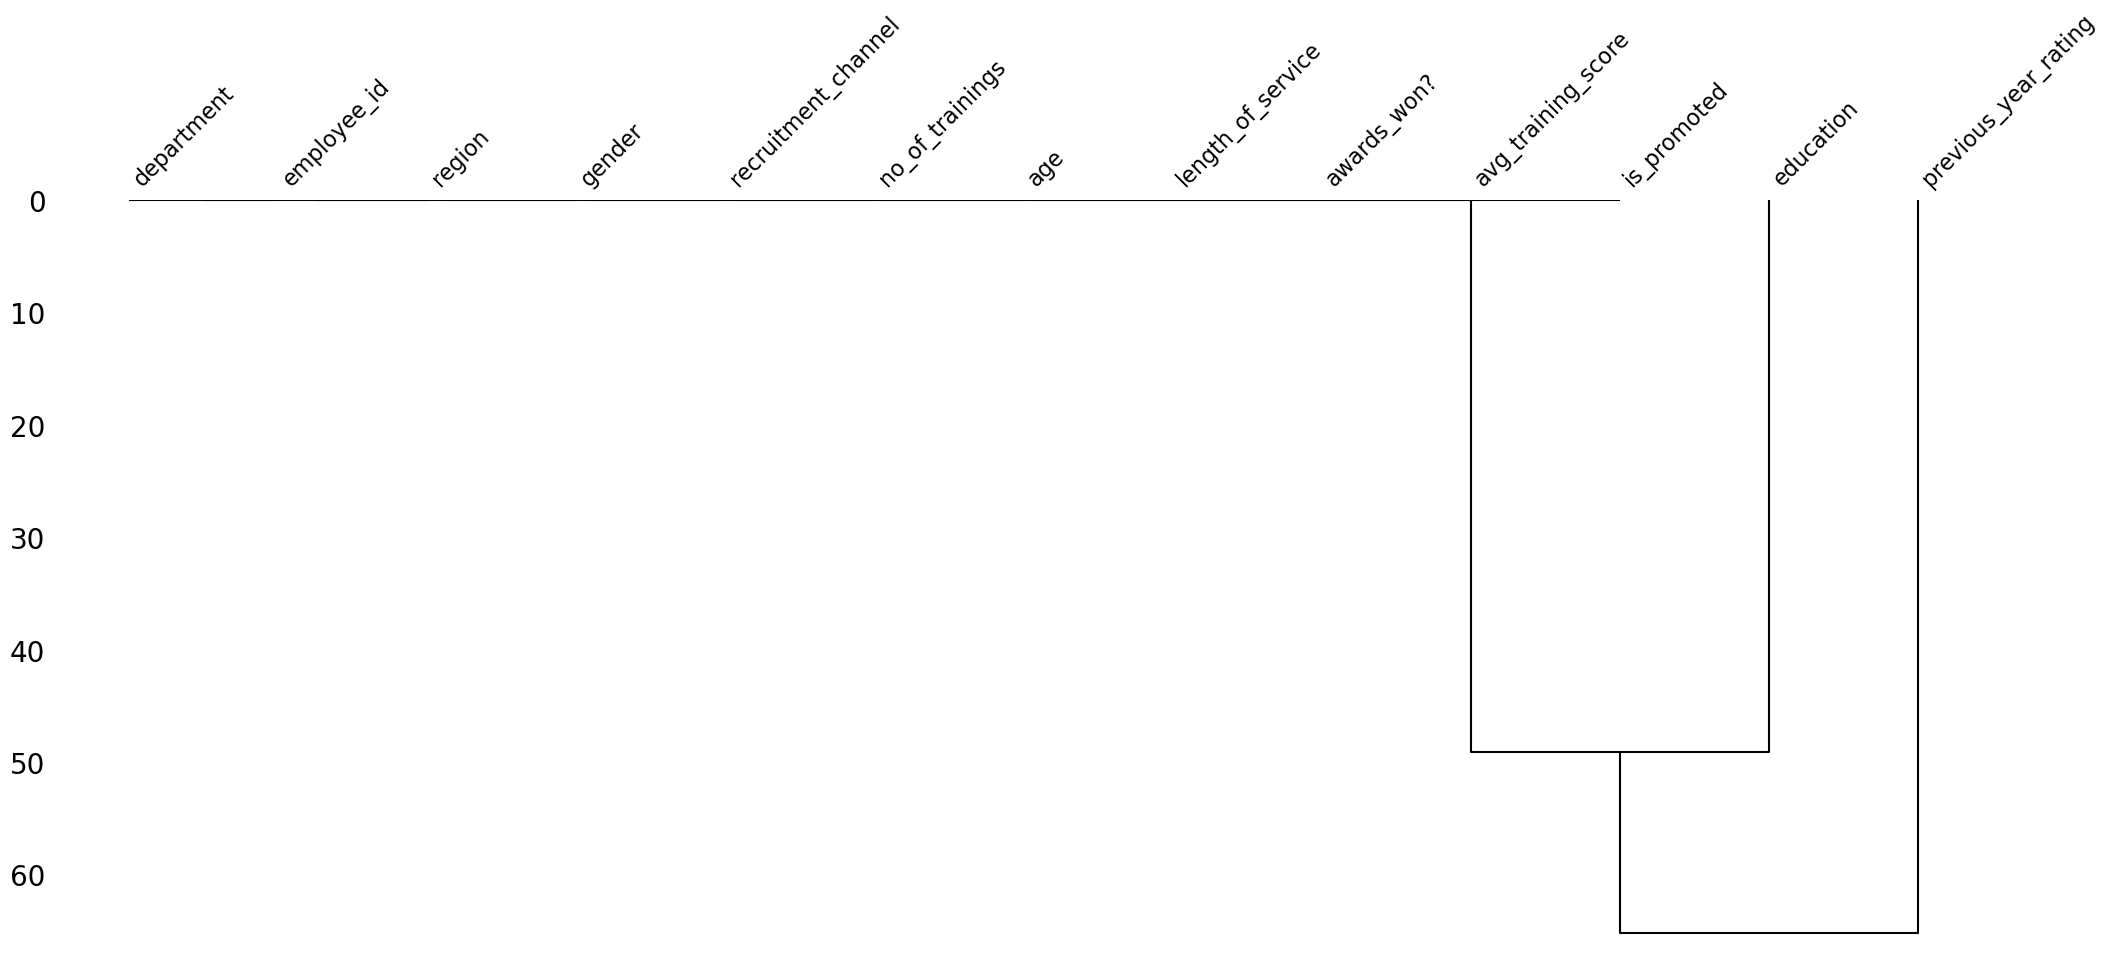

In [15]:
msno.dendrogram(df)

*The dendrogram shows that education and previous_year_rating share similar missing-value patterns, suggesting a dependency in how these variables are recorded. avg_training_score shows a weaker relationship with this cluster, while the remaining variables appear largely independent with respect to missingness.*

In [ ]:
df[df['length_of_service'] == 0]['previous_year_rating']

Series([], Name: previous_year_rating, dtype: float64)

*Clearly there is no one, which has 0 level of experience and stll present missing values in previous year rating*

In [25]:
df['education'].isnull().sum()

np.int64(2409)

In [24]:
df[df['previous_year_rating'].isnull()]['education'].isnull().sum() 

np.int64(385)

*There only 385 values in which education is null, where previous year is also null, very weak relationship,not dependent*